Imports y configuración

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# To be able to import src/ from the notebook
sys.path.append(os.path.dirname(os.getcwd()))

from src.config import METADATA_CSV, IMAGE_DIRS, CLASSES, FIGURES_DIR

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

os.makedirs(FIGURES_DIR, exist_ok=True)
print("Imports OK")

Imports OK


Load metadata

In [2]:
df = pd.read_csv(METADATA_CSV)
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst rows:")
df.head()

Shape: (10015, 7)

Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

First rows:


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


General information and null values

In [3]:
print("=== General info ===")
print(df.info())
print("\n=== Null values ===")
print(df.isnull().sum())
print(f"\nMean age: {df['age'].mean():.1f}")
print(f"Min age: {df['age'].min()} | Max age: {df['age'].max()}")

=== General info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB
None

=== Null values ===
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

Mean age: 51.9
Min age: 0.0 | Max age: 85.0


/tmp/ipykernel_3301737/1965953317.py:24: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(


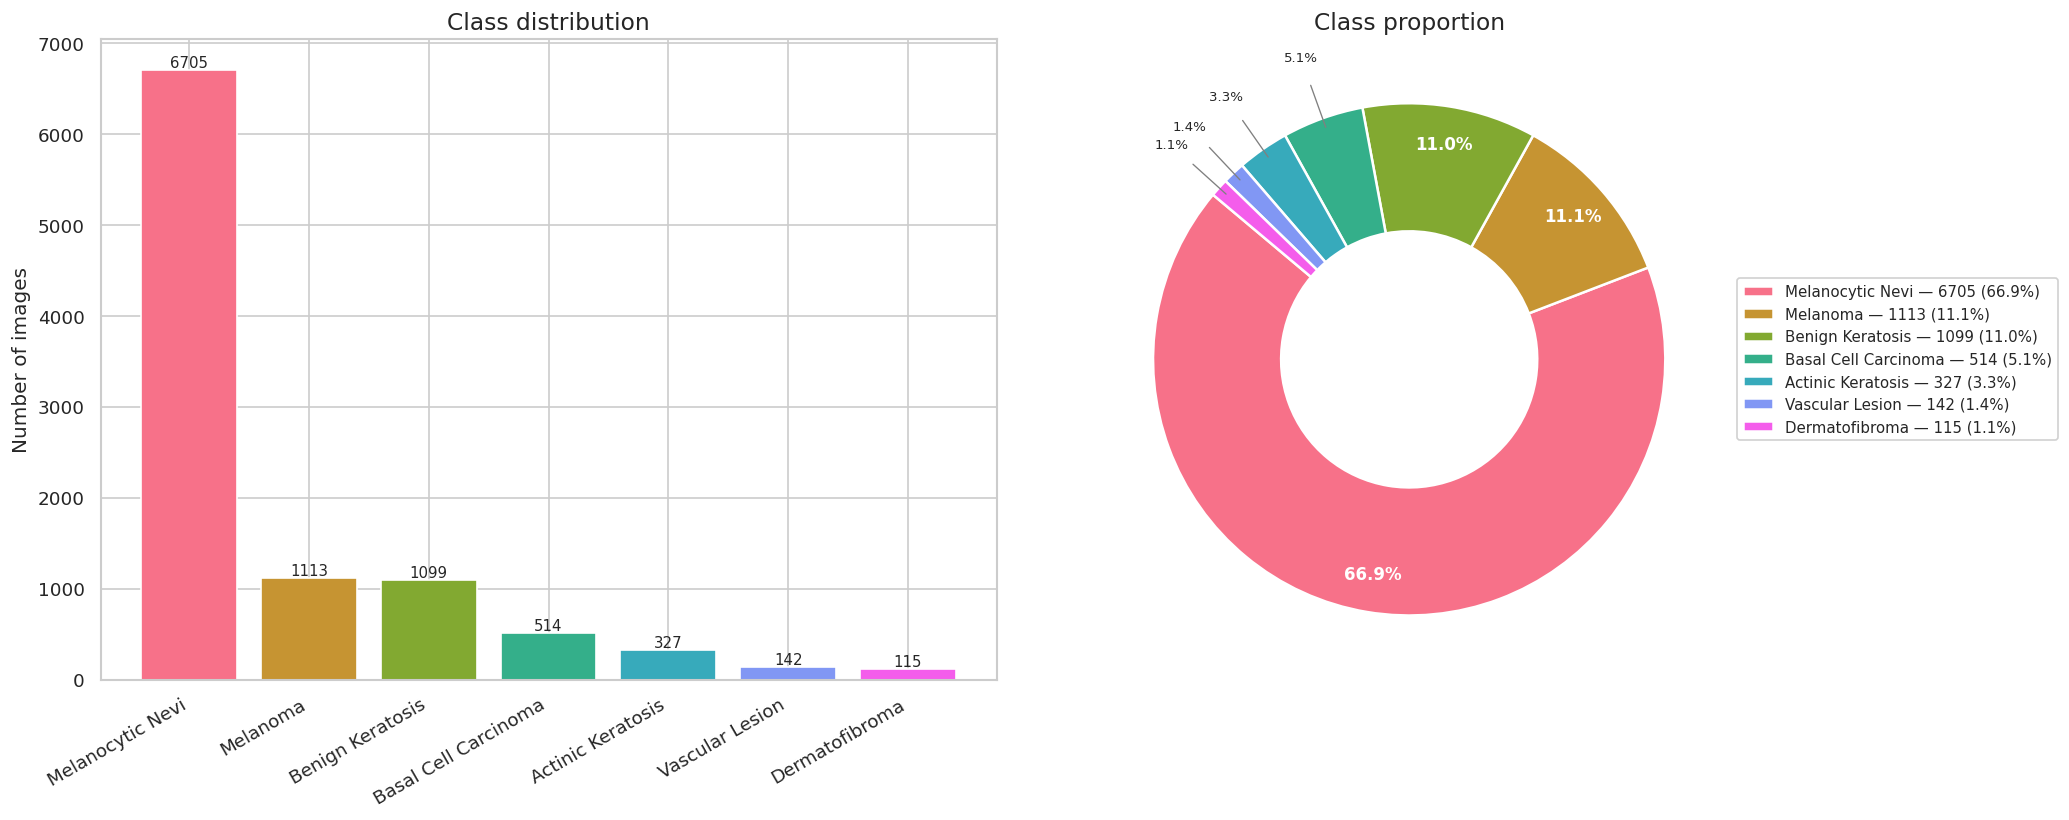

Saved: eda_class_distribution.png


In [11]:
class_names = {
    "akiec": "Actinic Keratosis",
    "bcc":   "Basal Cell Carcinoma",
    "bkl":   "Benign Keratosis",
    "df":    "Dermatofibroma",
    "mel":   "Melanoma",
    "nv":    "Melanocytic Nevi",
    "vasc":  "Vascular Lesion"
}

counts = df["dx"].value_counts()
colors = sns.color_palette("husl", len(CLASSES))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Barplot ───────────────────────────────────────────────────────────────────
axes[0].bar(
    [class_names[c] for c in counts.index],
    counts.values,
    color=colors
)
axes[0].set_title("Class distribution", fontsize=14)
axes[0].set_ylabel("Number of images")
axes[0].set_xticklabels(
    [class_names[c] for c in counts.index],
    rotation=30, ha="right"
)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontsize=9)

# ── Donut chart ───────────────────────────────────────────────────────────────
wedges, texts, autotexts = axes[1].pie(
    counts.values,
    autopct="%1.1f%%",
    colors=colors,
    startangle=140,
    pctdistance=0.85,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=1.5)
)

# Mover etiquetas de clases pequeñas hacia afuera
for i, (wedge, autotext) in enumerate(zip(wedges, autotexts)):
    pct = counts.values[i] / counts.sum() * 100
    if pct < 6:
        # Calcular ángulo central del sector
        ang = (wedge.theta2 + wedge.theta1) / 2
        ang_rad = np.deg2rad(ang)
        # Posición fuera del donut
        x = 1.25 * np.cos(ang_rad)
        y = 1.25 * np.sin(ang_rad)
        autotext.set_position((x, y))
        autotext.set_fontsize(8)
        # Línea desde el sector hasta la etiqueta
        axes[1].annotate(
            "",
            xy=(0.95 * np.cos(ang_rad), 0.95 * np.sin(ang_rad)),
            xytext=(x * 0.92, y * 0.92),
            arrowprops=dict(arrowstyle="-", color="gray", lw=0.8)
        )
    else:
        autotext.set_fontsize(10)
        autotext.set_fontweight("bold")
        autotext.set_color("white")

# Legend outside the plot
axes[1].legend(
    wedges,
    [f"{class_names[c]} — {v} ({v/counts.sum()*100:.1f}%)"
     for c, v in zip(counts.index, counts.values)],
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    fontsize=9,
    framealpha=0.9
)
axes[1].set_title("Class proportion", fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eda_class_distribution.png"), bbox_inches="tight")
plt.show()
print("Saved: eda_class_distribution.png")

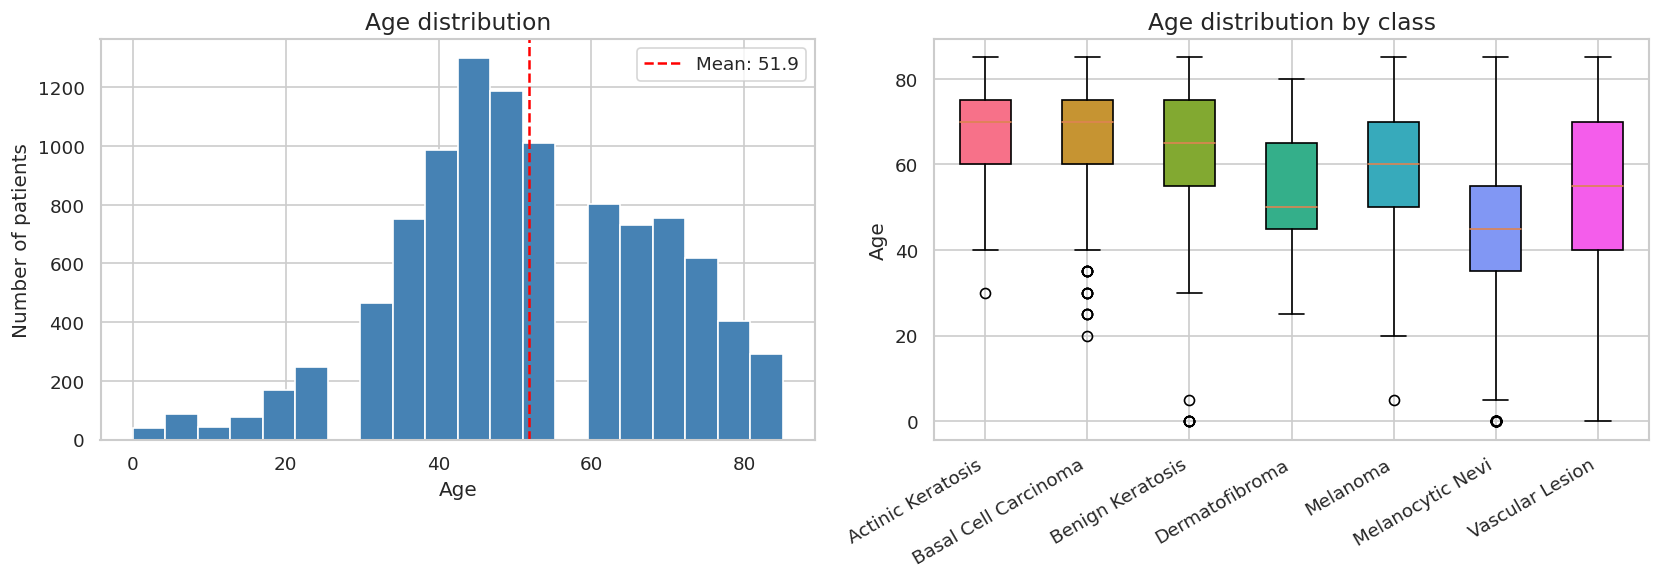

Null values in age: 57 (0.6%)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# General histogram
axes[0].hist(df["age"].dropna(), bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Age distribution", fontsize=14)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of patients")
axes[0].axvline(df["age"].mean(), color="red", linestyle="--", label=f"Mean: {df['age'].mean():.1f}")
axes[0].legend()

# Boxplot by class
age_data = [df[df["dx"] == cls]["age"].dropna().values for cls in CLASSES]
bp = axes[1].boxplot(age_data, patch_artist=True, labels=[class_names[c] for c in CLASSES])
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
axes[1].set_title("Age distribution by class", fontsize=14)
axes[1].set_xticklabels([class_names[c] for c in CLASSES], rotation=30, ha="right")
axes[1].set_ylabel("Age")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eda_age_distribution.png"), bbox_inches="tight")
plt.show()
print(f"Null values in age: {df['age'].isnull().sum()} ({df['age'].isnull().mean()*100:.1f}%)")

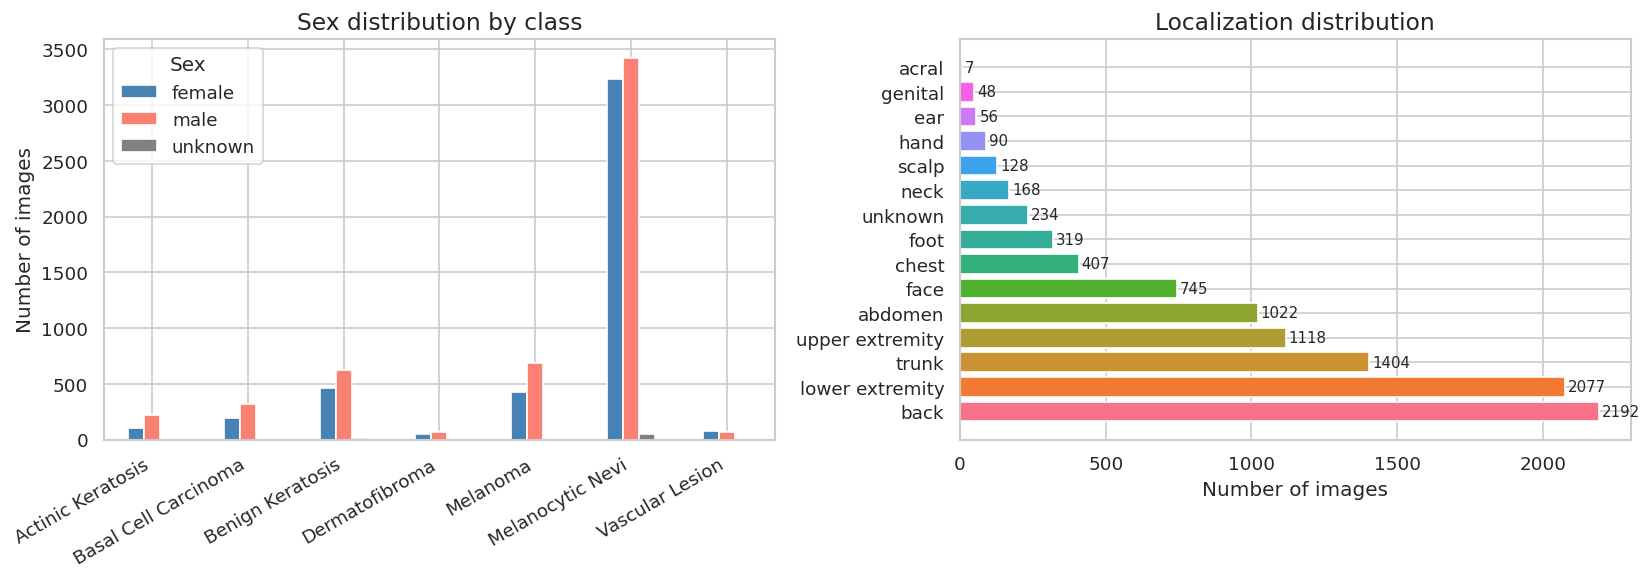

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sex by class
sex_counts = df.groupby(["dx", "sex"]).size().unstack(fill_value=0)
sex_counts.index = [class_names[c] for c in sex_counts.index]
sex_counts.plot(kind="bar", ax=axes[0], color=["steelblue", "salmon", "gray"], edgecolor="white")
axes[0].set_title("Sex distribution by class", fontsize=14)
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of images")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")
axes[0].legend(title="Sex")

# Localization
loc_counts = df["localization"].value_counts()
axes[1].barh(loc_counts.index, loc_counts.values, color=sns.color_palette("husl", len(loc_counts)))
axes[1].set_title("Localization distribution", fontsize=14)
axes[1].set_xlabel("Number of images")
for i, v in enumerate(loc_counts.values):
    axes[1].text(v + 10, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eda_sex_localization.png"), bbox_inches="tight")
plt.show()

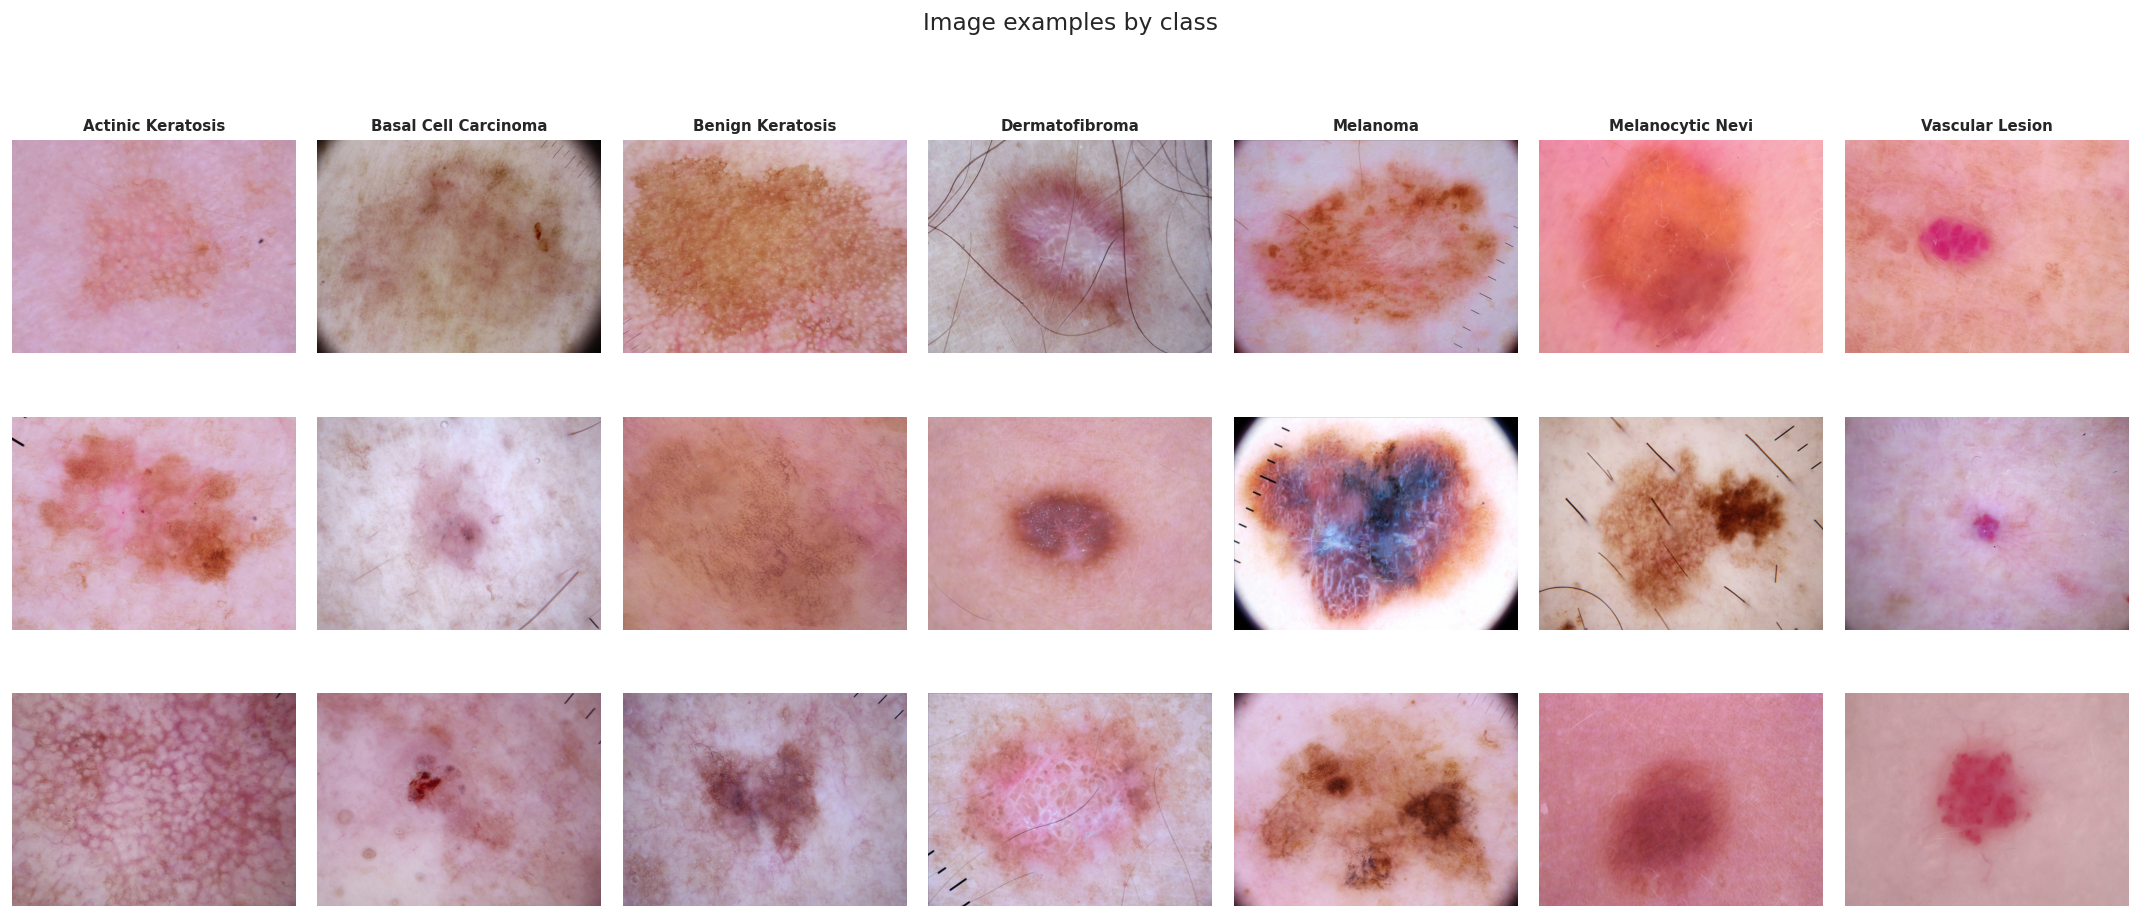

Saved: eda_image_examples.png


In [14]:
import cv2

def find_image_path(image_id):
    for folder in IMAGE_DIRS:
        path = os.path.join(folder, image_id + ".jpg")
        if os.path.exists(path):
            return path
    return None

fig, axes = plt.subplots(3, 7, figsize=(18, 8))

for col, cls in enumerate(CLASSES):
    samples = df[df["dx"] == cls].sample(3, random_state=42)
    for row, (_, sample) in enumerate(samples.iterrows()):
        path = find_image_path(sample["image_id"])
        img  = cv2.imread(path)
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(class_names[cls], fontsize=9, fontweight="bold")

plt.suptitle("Image examples by class", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eda_image_examples.png"), bbox_inches="tight")
plt.show()
print("Saved: eda_image_examples.png")

In [15]:
print("=" * 50)
print("HAM10000 DATASET SUMMARY")
print("=" * 50)

print(f"\nTotal images        : {len(df)}")
print(f"Total classes       : {len(CLASSES)}")
print(f"Mean age ± std      : {df['age'].mean():.1f} ± {df['age'].std():.1f}")
print(f"Age range           : {int(df['age'].min())} - {int(df['age'].max())} years")
print(f"Null values in age  : {df['age'].isnull().sum()} ({df['age'].isnull().mean()*100:.1f}%)")

print(f"\n--- Sex distribution ---")
print(df["sex"].value_counts())

print(f"\n--- Class distribution ---")
for cls in CLASSES:
    n = len(df[df["dx"] == cls])
    print(f"  {class_names[cls]:<25} : {n:4d} ({n/len(df)*100:.1f}%)")

print(f"\n--- Class imbalance ---")
max_cls = df["dx"].value_counts().index[0]
min_cls = df["dx"].value_counts().index[-1]
ratio   = df["dx"].value_counts()[max_cls] / df["dx"].value_counts()[min_cls]
print(f"  Majority class    : {class_names[max_cls]} ({df['dx'].value_counts()[max_cls]})")
print(f"  Minority class    : {class_names[min_cls]} ({df['dx'].value_counts()[min_cls]})")
print(f"  Imbalance ratio   : {ratio:.1f}x")

print(f"\n--- Unique localizations ---")
print(f"  {df['localization'].nunique()} distinct localizations")
print(df["localization"].value_counts().head(5))

HAM10000 DATASET SUMMARY

Total images        : 10015
Total classes       : 7
Mean age ± std      : 51.9 ± 17.0
Age range           : 0 - 85 years
Null values in age  : 57 (0.6%)

--- Sex distribution ---
sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64

--- Class distribution ---
  Actinic Keratosis         :  327 (3.3%)
  Basal Cell Carcinoma      :  514 (5.1%)
  Benign Keratosis          : 1099 (11.0%)
  Dermatofibroma            :  115 (1.1%)
  Melanoma                  : 1113 (11.1%)
  Melanocytic Nevi          : 6705 (66.9%)
  Vascular Lesion           :  142 (1.4%)

--- Class imbalance ---
  Majority class    : Melanocytic Nevi (6705)
  Minority class    : Dermatofibroma (115)
  Imbalance ratio   : 58.3x

--- Unique localizations ---
  15 distinct localizations
localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
Name: count, dtype: int64
